<a href="https://colab.research.google.com/github/abdullaiev-ramil/Analytics/blob/main/Exploratory_data_analysis_for_online_shop.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Завантаження датасету та опис даних

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


from google.colab import drive
drive.mount("/content/drive")

%cd /content/drive/MyDrive/Ramil

df_countries = pd.read_csv("countries.csv")
df_countries.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/Ramil


,name,alpha-2,alpha-3,region,sub-region
0,Afghanistan,AF,AFG,Asia,Southern Asia
1,Åland Islands,AX,ALA,Europe,Northern Europe
2,Albania,AL,ALB,Europe,Southern Europe
3,Algeria,DZ,DZA,Africa,Northern Africa
4,American Samoa,AS,ASM,Oceania,Polynesia


In [ ]:
print(f"Кількість рядків та колонок у датасеті з країнами:{df_countries.shape}")

Кількість рядків та колонок у датасеті з країнами:(249, 5)


In [ ]:
print(f"Загальна інформація про датасет:\n\n{df_countries.info}")

Загальна інформація про датасет:

<bound method DataFrame.info of                   name alpha-2 alpha-3   region          sub-region
0          Afghanistan      AF     AFG     Asia       Southern Asia
1        Åland Islands      AX     ALA   Europe     Northern Europe
2              Albania      AL     ALB   Europe     Southern Europe
3              Algeria      DZ     DZA   Africa     Northern Africa
4       American Samoa      AS     ASM  Oceania           Polynesia
..                 ...     ...     ...      ...                 ...
244  Wallis and Futuna      WF     WLF  Oceania           Polynesia
245     Western Sahara      EH     ESH   Africa     Northern Africa
246              Yemen      YE     YEM     Asia        Western Asia
247             Zambia      ZM     ZMB   Africa  Sub-Saharan Africa
248           Zimbabwe      ZW     ZWE   Africa  Sub-Saharan Africa

[249 rows x 5 columns]>


In [ ]:
print(f"Типи даних у кожному стовпчику:\n\n{df_countries.dtypes}")

Типи даних у кожному стовпчику:

name          object
alpha-2       object
alpha-3       object
region        object
sub-region    object
dtype: object


In [ ]:
df_events = pd.read_csv("events.csv")
df_events.head()

,Order ID,Order Date,Ship Date,Order Priority,Country Code,Product ID,Sales Channel,Units Sold,Unit Price,Unit Cost
0,100640618,10/8/2014,10/18/2014,M,NOR,2103,Online,650.0,205.70,117.11
1,100983083,8/11/2016,8/11/2016,C,SRB,2103,Offline,1993.0,205.70,117.11
2,101025998,7/18/2014,8/11/2014,M,NaN,7940,Online,4693.0,668.27,502.54
3,102230632,5/13/2017,6/13/2017,L,MNE,2455,Online,1171.0,109.28,35.84
4,103435266,8/11/2012,9/18/2012,H,SRB,1270,Offline,7648.0,47.45,31.79


In [ ]:
print(f"Кількість рядків та колонок у датасеті з івентами:{df_events.shape}")

Кількість рядків та колонок у датасеті з івентами:(1330, 10)


In [ ]:
print(f"Загальна інформація про датасет:\n\n{df_events.info}")

Загальна інформація про датасет:

<bound method DataFrame.info of        Order ID Order Date   Ship Date Order Priority Country Code  \
0     100640618  10/8/2014  10/18/2014              M          NOR   
1     100983083  8/11/2016   8/11/2016              C          SRB   
2     101025998  7/18/2014   8/11/2014              M          NaN   
3     102230632  5/13/2017   6/13/2017              L          MNE   
4     103435266  8/11/2012   9/18/2012              H          SRB   
...         ...        ...         ...            ...          ...   
1325  994504153  1/10/2017   1/13/2017              M          SWE   
1326  994978797  12/5/2014    1/2/2015              H          ITA   
1327  996754205  9/20/2010   9/22/2010              L          RUS   
1328  998043382  6/15/2010    7/3/2010              H          MLT   
1329  999879729  3/31/2012    5/6/2012              M          ALB   

      Product ID Sales Channel  Units Sold  Unit Price  Unit Cost  
0           2103        O

In [ ]:
print(f"Типи даних у кожному стовпчику:\n\n{df_events.dtypes}")

Типи даних у кожному стовпчику:

Order ID            int64
Order Date         object
Ship Date          object
Order Priority     object
Country Code       object
Product ID          int64
Sales Channel      object
Units Sold        float64
Unit Price        float64
Unit Cost         float64
dtype: object


Бачимо,що колонки Order Date та Ship Date мають не коректний тип даних

In [ ]:
df_products = pd.read_csv("products.csv")
df_products.head()

,id,item_type
0,2103,Cereal
1,7940,Household
2,2455,Clothes
3,1270,Beverages
4,8681,Office Supplies


In [ ]:
print(f"Кількість рядків та колонок у датасеті з категоріми продуктів:{df_products.shape}")

Кількість рядків та колонок у датасеті з категоріми продуктів:(12, 2)


In [ ]:
print(f"Загальна інформація про датасет:\n\n{df_products.info}")

Загальна інформація про датасет:

<bound method DataFrame.info of       id        item_type
0   2103           Cereal
1   7940        Household
2   2455          Clothes
3   1270        Beverages
4   8681  Office Supplies
5   4594           Fruits
6   5988       Vegetables
7   7331        Baby Food
8   8875             Meat
9   8293        Cosmetics
10  8969           Snacks
11  3127    Personal Care>


In [ ]:
print(f"Типи даних у кожному стовпчику:\n\n{df_products.dtypes}")

Типи даних у кожному стовпчику:

id            int64
item_type    object
dtype: object


###Опис таблиць
1. **events.csv**

Основна таблиця, яка містить інформацію про продажі товарів.

**Основні колонки**:

Order Date — дата замовлення.

Ship Date — дата відвантаження товару.

Country Code — код країни.

Product Code — код товару.

Units Sold — кількість проданих одиниць.

Unit Price — ціна за одиницю товару.

Unit Cost — собівартість одиниці товару.

Total Revenue — дохід від продажу.

Total Cost — загальна собівартість.

Total Profit — прибуток.

2. **products.csv**

Довідник товарів.

**Основні колонки**:

Product Code — унікальний код товару.

Product Category — категорія товару.

3. **countries.csv**

Довідник країн.

**Основні колонки**:

Country Code — унікальний код країни.

Country — назва країни.

Region — регіон

# Робота із пропущеними даними, некоректними даними, аномаліями.

##Перевірка на пропущення даних з датасету по країнам

In [ ]:
print(df_countries.isna().sum())

name          0
alpha-2       1
alpha-3       0
region        1
sub-region    1
dtype: int64


In [ ]:
df_countries["alpha-2"] = df_countries["alpha-2"].fillna("Unknown")
df_countries["region"] = df_countries["region"].fillna("Unknown")
df_countries["sub-region"] = df_countries["sub-region"].fillna("Unknown")

Пропущені значення не були видалені, оскільки таблиця буде використовуватися для подальшого об'єднання з іншими наборами даних.Видалення рядків могло б призвести до втрати зв'язків між таблицями.

##Виявимо чи є дублікати в датасеті по країнах

In [ ]:
dublicate_rows_country = df_countries.duplicated()
print(dublicate_rows_country)
print(dublicate_rows_country.sum())

0      False
1      False
2      False
3      False
4      False
       ...  
244    False
245    False
246    False
247    False
248    False
Length: 249, dtype: bool
0


In [ ]:
df_countries.value_counts()

,,,,,count
name,alpha-2,alpha-3,region,sub-region,
Afghanistan,AF,AFG,Asia,Southern Asia,1
Albania,AL,ALB,Europe,Southern Europe,1
Algeria,DZ,DZA,Africa,Northern Africa,1
American Samoa,AS,ASM,Oceania,Polynesia,1
Andorra,AD,AND,Europe,Southern Europe,1
...,...,...,...,...,...
Western Sahara,EH,ESH,Africa,Northern Africa,1
Yemen,YE,YEM,Asia,Western Asia,1
Zambia,ZM,ZMB,Africa,Sub-Saharan Africa,1


Дублікатів не виявленно




##Перевірка на пропущення даних з датасету по івентам




In [ ]:
print(df_events.isna().sum())

Order ID           0
Order Date         0
Ship Date          0
Order Priority     0
Country Code      82
Product ID         0
Sales Channel      0
Units Sold         2
Unit Price         0
Unit Cost          0
dtype: int64


In [ ]:
print(df_events.isna().sum() / df_events.shape[0] * 100)

Order ID          0.000000
Order Date        0.000000
Ship Date         0.000000
Order Priority    0.000000
Country Code      6.165414
Product ID        0.000000
Sales Channel     0.000000
Units Sold        0.150376
Unit Price        0.000000
Unit Cost         0.000000
dtype: float64


In [ ]:
df_events["Country Code"] = df_events["Country Code"].fillna("UNK")

Пропуски були заповнені значенням "UNK" для збереження всіх записів та можливості подальшого аналізу.

In [ ]:
df_events = df_events.dropna(subset=["Units Sold"])

У стовпці Units Sold було виявлено 2 пропущені значення. Оскільки дана змінна є ключовою для розрахунку основних бізнес-метрик важливо зберегти точність фактичних даних.

In [ ]:
df_events[["Units Sold", "Unit Price", "Unit Cost"]].describe()

,Units Sold,Unit Price,Unit Cost
count,1328.000000,1328.000000,1328.000000
mean,4952.201807,264.913245,187.211521
std,2905.198996,217.386320,176.187801
min,2.000000,9.330000,6.920000
25%,2356.750000,81.730000,35.840000
50%,4962.000000,154.060000,97.440000
75%,7459.500000,437.200000,263.330000
max,9999.000000,668.270000,524.960000


Було проведено аналіз описової статистики змінних Units Sold, Unit Price та Unit Cost. Явних аномальних значень або помилок у даних не виявлено, оскільки мінімальні та максимальні значення знаходяться в логічних межах.

##Перетворимо колонки Order Date та Ship Date на формат дати

In [ ]:
df_events["Order Date"] = pd.to_datetime(df_events["Order Date"], dayfirst=False)
df_events["Ship Date"] = pd.to_datetime(df_events["Ship Date"], dayfirst=False)

In [ ]:
df_events.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1328 entries, 0 to 1329
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Order ID        1328 non-null   int64         
 1   Order Date      1328 non-null   datetime64[ns]
 2   Ship Date       1328 non-null   datetime64[ns]
 3   Order Priority  1328 non-null   object        
 4   Country Code    1328 non-null   object        
 5   Product ID      1328 non-null   int64         
 6   Sales Channel   1328 non-null   object        
 7   Units Sold      1328 non-null   float64       
 8   Unit Price      1328 non-null   float64       
 9   Unit Cost       1328 non-null   float64       
dtypes: datetime64[ns](2), float64(3), int64(2), object(3)
memory usage: 114.1+ KB


##Виявимо чи є дублікати в датасеті по івентах

In [ ]:
df_events["Sales Channel"].unique()

array(['Online', 'Offline', 'online'], dtype=object)

In [ ]:
df_events["Sales Channel"] = df_events["Sales Channel"].str.strip().str.title()

In [ ]:
dublicate_rows_events = df_events.duplicated()
print(dublicate_rows_events)
print(dublicate_rows_events.sum())

0       False
1       False
2       False
3       False
4       False
        ...  
1325    False
1326    False
1327    False
1328    False
1329    False
Length: 1328, dtype: bool
0


In [ ]:
df_events.value_counts()

,,,,,,,,,,count
Order ID,Order Date,Ship Date,Order Priority,Country Code,Product ID,Sales Channel,Units Sold,Unit Price,Unit Cost,
987459170,2010-07-16,2010-08-27,M,UKR,3127,Online,9967.0,81.73,56.67,1
987410676,2014-08-13,2014-09-06,C,AUT,2103,Offline,5616.0,205.70,117.11,1
987050187,2012-04-12,2012-04-25,C,MKD,5988,Online,8940.0,154.06,90.93,1
986449801,2013-01-31,2013-03-13,H,ALB,8875,Offline,1272.0,421.89,364.69,1
985417258,2011-10-01,2011-10-21,M,GBR,2103,Online,5720.0,205.70,117.11,1
...,...,...,...,...,...,...,...,...,...,...
103435266,2012-08-11,2012-09-18,H,SRB,1270,Offline,7648.0,47.45,31.79,1
102230632,2017-05-13,2017-06-13,L,MNE,2455,Online,1171.0,109.28,35.84,1
101025998,2014-07-18,2014-08-11,M,UNK,7940,Online,4693.0,668.27,502.54,1


Дублікатів не виявленно

##Перевірка на пропущення даних з датасету по категоріям продуктів

In [ ]:
print(df_products.isna().sum())

id           0
item_type    0
dtype: int64


##Виявимо чи є дублікати в датасеті по категоріях продуктів

In [ ]:
dublicate_rows_products = df_products.duplicated()
print(dublicate_rows_products)
print(dublicate_rows_products.sum())

0     False
1     False
2     False
3     False
4     False
5     False
6     False
7     False
8     False
9     False
10    False
11    False
dtype: bool
0


In [ ]:
df_products.value_counts()

,,count
id,item_type,
1270,Beverages,1
2103,Cereal,1
2455,Clothes,1
3127,Personal Care,1
4594,Fruits,1
5988,Vegetables,1
7331,Baby Food,1
7940,Household,1
8293,Cosmetics,1


Дублікатів не виявленно

#Обьеднання таблиць

In [ ]:
merged = df_events.merge(
    df_countries,
    left_on ="Country Code",
    right_on ="alpha-3",
    how ="left"
)
data = merged.merge(
    df_products,
    left_on = "Product ID",
    right_on = "id",
    how = "left"
)
data.head()

,Order ID,Order Date,Ship Date,Order Priority,Country Code,Product ID,Sales Channel,Units Sold,Unit Price,Unit Cost,name,alpha-2,alpha-3,region,sub-region,id,item_type
0,100640618,2014-10-08,2014-10-18,M,NOR,2103,Online,650.0,205.70,117.11,Norway,NO,NOR,Europe,Northern Europe,2103,Cereal
1,100983083,2016-08-11,2016-08-11,C,SRB,2103,Offline,1993.0,205.70,117.11,Serbia,RS,SRB,Europe,Southern Europe,2103,Cereal
2,101025998,2014-07-18,2014-08-11,M,UNK,7940,Online,4693.0,668.27,502.54,NaN,NaN,NaN,NaN,NaN,7940,Household
3,102230632,2017-05-13,2017-06-13,L,MNE,2455,Online,1171.0,109.28,35.84,Montenegro,ME,MNE,Europe,Southern Europe,2455,Clothes
4,103435266,2012-08-11,2012-09-18,H,SRB,1270,Offline,7648.0,47.45,31.79,Serbia,RS,SRB,Europe,Southern Europe,1270,Beverages


##Прибирання зайвих колонок,додавання нових та замінимо назви колонок

In [ ]:
#Прибираємо зайві колонки
clean_data = data.drop(["id", "alpha-2"], axis=1)
clean_data = data.drop(["id", "alpha-3"], axis=1)

#Змінюємо необхідні назви колонок на більш зручні
clean_data = clean_data.rename(columns={"name": "Country"})
clean_data = clean_data.rename(columns={"item_type": "Product Category"})

#Додаємо потрібні колонки
clean_data["Cost"] = (
    clean_data["Units Sold"] * clean_data["Unit Cost"]
)

clean_data["Revenue"] = (
    clean_data["Units Sold"] * clean_data["Unit Price"]
)

clean_data["Profit"] = (
    clean_data["Revenue"] - clean_data["Cost"]
)

clean_data["Time Delay"] = (
    clean_data["Ship Date"] - clean_data["Order Date"]
).dt.days

clean_data["Year"] = clean_data["Order Date"].dt.to_period("Y").dt.to_timestamp()

clean_data["Month"] = clean_data["Order Date"].dt.to_period("M").dt.to_timestamp()

clean_data["Day of Week"] = clean_data["Order Date"].dt.day_name()
clean_data.head()

,Order ID,Order Date,Ship Date,Order Priority,Country Code,Product ID,Sales Channel,Units Sold,Unit Price,Unit Cost,...,region,sub-region,Product Category,Cost,Revenue,Profit,Time Delay,Year,Month,Day of Week
0,100640618,2014-10-08,2014-10-18,M,NOR,2103,Online,650.0,205.70,117.11,...,Europe,Northern Europe,Cereal,76121.50,133705.00,57583.50,10,2014-01-01,2014-10-01,Wednesday
1,100983083,2016-08-11,2016-08-11,C,SRB,2103,Offline,1993.0,205.70,117.11,...,Europe,Southern Europe,Cereal,233400.23,409960.10,176559.87,0,2016-01-01,2016-08-01,Thursday
2,101025998,2014-07-18,2014-08-11,M,UNK,7940,Online,4693.0,668.27,502.54,...,NaN,NaN,Household,2358420.22,3136191.11,777770.89,24,2014-01-01,2014-07-01,Friday
3,102230632,2017-05-13,2017-06-13,L,MNE,2455,Online,1171.0,109.28,35.84,...,Europe,Southern Europe,Clothes,41968.64,127966.88,85998.24,31,2017-01-01,2017-05-01,Saturday
4,103435266,2012-08-11,2012-09-18,H,SRB,1270,Offline,7648.0,47.45,31.79,...,Europe,Southern Europe,Beverages,243129.92,362897.60,119767.68,38,2012-01-01,2012-08-01,Saturday


#Основні метрики

In [ ]:
total_orders = clean_data["Order ID"].count()

total_revenue = clean_data["Revenue"].sum()
total_cost = clean_data["Cost"].sum()
total_profit = clean_data["Profit"].sum()
total_units_sold = clean_data["Units Sold"].sum()

avg_time_delay = (clean_data["Time Delay"]).mean()

total_countries = clean_data["Country"].nunique()
print(f"Загальна кільість замовлень: {total_orders}")
print(f"Загальний дохід: {total_revenue}")
print(f"Загальна вартість: {total_cost}")
print(f"Загальний прибуток: {total_profit}")
print(f"Загальна кількість проданих одиниць:{total_units_sold}")
print(f"Середній час доставки (по днях): {avg_time_delay}")
print(f"Загальна кількість охоплених країн: {total_countries}")


Загальна кільість замовлень: 1328
Загальний дохід: 1702129408.21
Загальна вартість: 1200694949.21
Загальний прибуток: 501434459.0
Загальна кількість проданих одиниць:6576524.0
Середній час доставки (по днях): 24.786897590361445
Загальна кількість охоплених країн: 45


#Аналіз продажів по категоріям продукту

In [ ]:
category_metrics = clean_data.groupby("Product Category").agg(
    Revenue = ("Revenue", "sum"),
    Cost = ("Cost", "sum"),
    Profit = ("Profit", "sum"),
    Units_Sold = ("Units Sold", "sum")
)
category_metrics.head()

,Revenue,Cost,Profit,Units_Sold
Product Category,,,,
Baby Food,1.436476e+08,8.970659e+07,53940997.16,562706.0
Beverages,2.909316e+07,1.949150e+07,9601662.78,613133.0
Cereal,9.579140e+07,5.453637e+07,41255034.15,465685.0
Clothes,6.462655e+07,2.119524e+07,43431314.40,591385.0
Cosmetics,2.331548e+08,1.404315e+08,92723306.17,533291.0


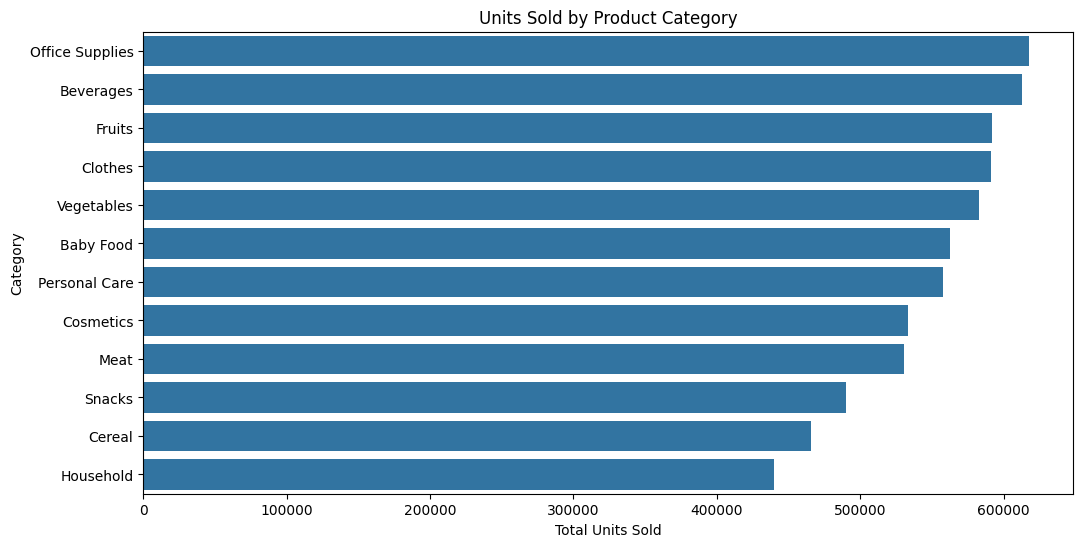

In [ ]:
popular_categories = clean_data.groupby("Product Category")["Units Sold"].sum().sort_values(ascending=False)

plt.figure(figsize=(12,6))
sns.barplot(y=popular_categories.index, x=popular_categories.values, errorbar=None,)
plt.title("Units Sold by Product Category")
plt.ylabel("Category")
plt.xlabel("Total Units Sold")
plt.show()

Бачимо,що найбільш продавана категорія: Office Supplies \
Найменш: Household


#Аналіз продажів по країнам


In [ ]:
country_metrics = clean_data.groupby("Country").agg(
    Revenue = ("Revenue", "sum"),
    Cost = ("Cost","sum"),
    Profit = ("Profit", "sum"),
    Units_Sold = ("Units Sold", "sum")
)
country_metrics.head()

,Revenue,Cost,Profit,Units_Sold
Country,,,,
Albania,32224853.87,21734147.85,10490706.02,90608.0
Andorra,47756693.17,32346656.54,15410036.63,185686.0
Armenia,37519840.21,28097487.03,9422353.18,150665.0
Austria,35740871.49,25713361.85,10027509.64,145573.0
Belarus,34236260.77,22383839.72,11852421.05,153432.0


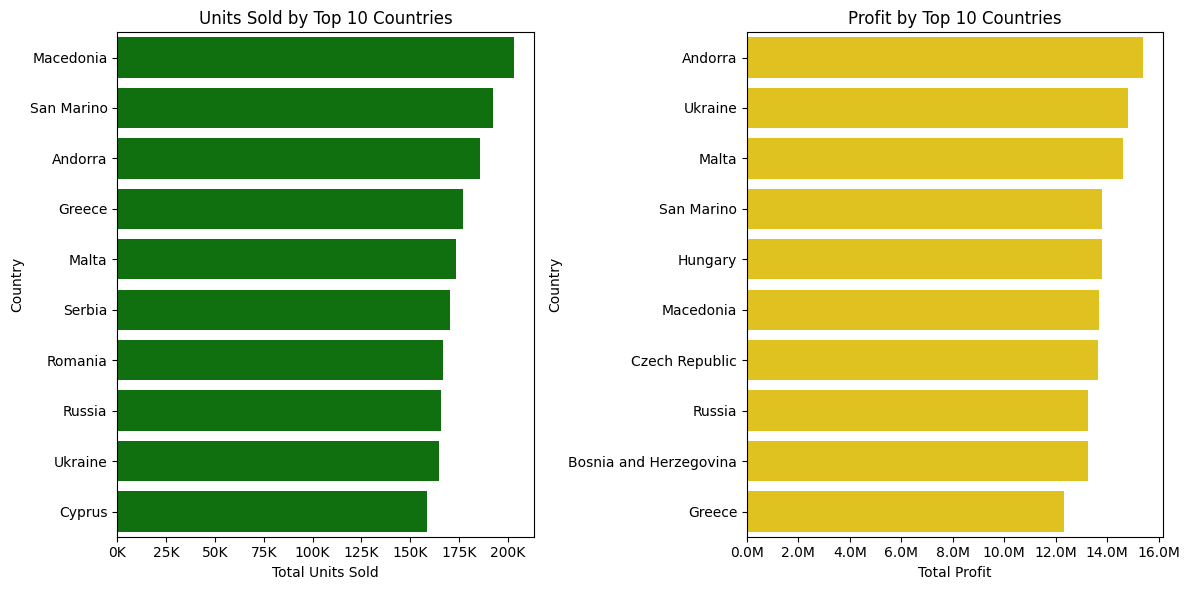

In [ ]:
import matplotlib.ticker as ticker
top_units = clean_data.groupby("Country")["Units Sold"].sum().sort_values(ascending=False).head(10)
top_profit = clean_data.groupby("Country")["Profit"].sum().sort_values(ascending=False).head(10)

fig, ax = plt.subplots(1, 2, figsize=(12, 6))

sns.barplot(y=top_units.index, x=top_units.values, color="Green", errorbar=None, ax=ax[0])
ax[0].set_title("Units Sold by Top 10 Countries")
ax[0].set_xlabel("Total Units Sold")
ax[0].set_ylabel("Country")
ax[0].xaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, pos: f'{x/1000:.0f}K')
)

sns.barplot(y=top_profit.index, x=top_profit.values, color="Gold", errorbar=None, ax=ax[1])
ax[1].set_title("Profit by Top 10 Countries")
ax[1].set_xlabel("Total Profit")
ax[1].set_ylabel("Country")

ax[1].xaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, pos: f'{x/1e6:.1f}M')
)



plt.tight_layout()
plt.show()

Македонія, Сан-Марино та Андорра мають найвищі показники за кількістю проданих одиниць товару.

Найбільший прибуток компанія отримала в Андоррі, Україні та на Мальті.

## Аналіз продажів по регіонам


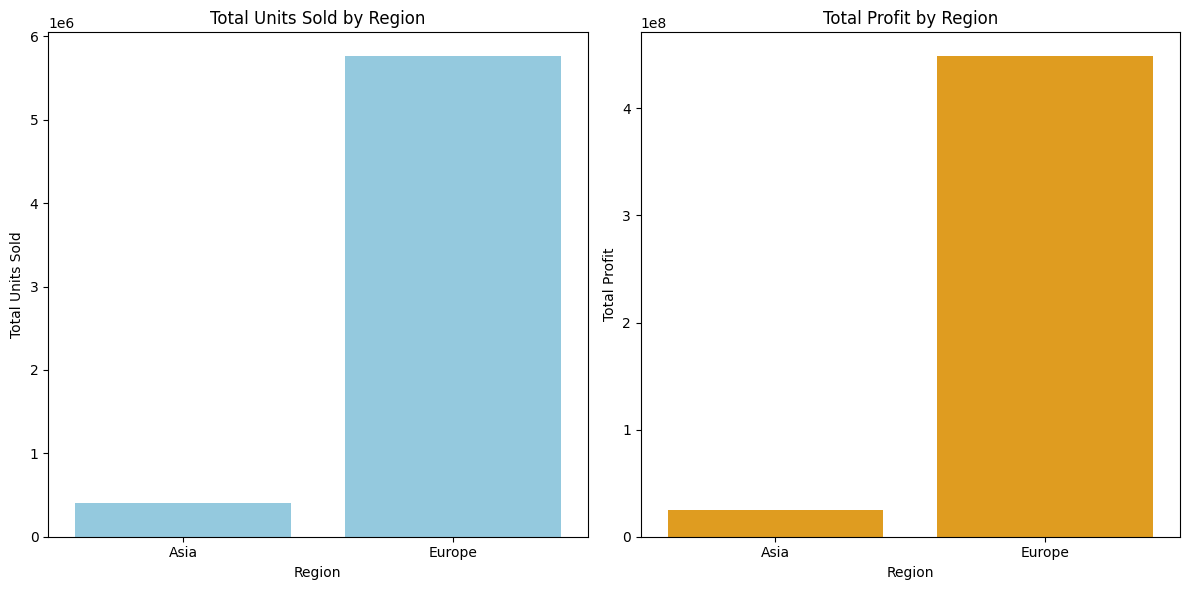

In [ ]:
units_sold_by_region = clean_data.groupby("region")["Units Sold"].sum()
profit_by_region = clean_data.groupby("region")["Profit"].sum()

fig, ax = plt.subplots(1, 2, figsize=(12, 6))
sns.barplot(x = units_sold_by_region.index, y = units_sold_by_region.values, color= "Skyblue", errorbar= None,ax=ax[0])
ax[0].set_title("Total Units Sold by Region")
ax[0].set_xlabel("Region")
ax[0].set_ylabel("Total Units Sold")


sns.barplot(x = profit_by_region.index, y = profit_by_region.values, color= "Orange", errorbar= None, ax=ax[1])
ax[1].set_title("Total Profit by Region")
ax[1].set_xlabel("Region")
ax[1].set_ylabel("Total Profit")


plt.tight_layout()
plt.show()


За графіком видно, що Європа значно випереджає Азію як за кількістю проданих одиниць товару, так і за загальним прибутком. Це означає, що основна частина продажів компанії припадає саме на європейський регіон.

#Аналіз продажів по каналів продажу

In [ ]:
channels = clean_data.groupby("Sales Channel").agg(
    Revenue = ("Revenue", "sum"),
    Cost = ("Cost", "sum"),
    Profit = ("Profit", "sum"),
    Units_Sold = ("Units Sold", "sum")
)
channels.head()

,Revenue,Cost,Profit,Units_Sold
Sales Channel,,,,
Offline,8.717606e+08,6.182941e+08,2.534665e+08,3320363.0
Online,8.303688e+08,5.824008e+08,2.479679e+08,3256161.0


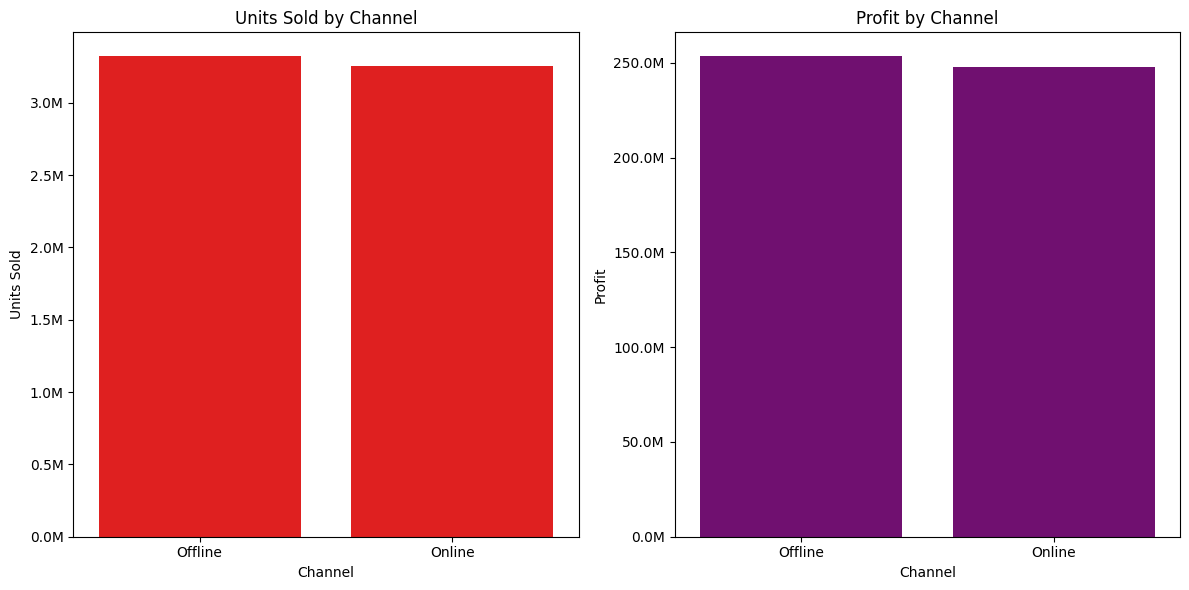

In [ ]:
channel_units_sold = channels["Units_Sold"]
channel_profit = channels["Profit"]

fig, ax = plt.subplots(1, 2, figsize=(12, 6))

sns.barplot(x=channel_units_sold.index, y=channel_units_sold.values, color="Red", errorbar=None, ax=ax[0])
ax[0].set_title("Units Sold by Channel")
ax[0].set_ylabel("Units Sold")
ax[0].set_xlabel("Channel")
ax[0].yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, pos: f'{x/1e6:.1f}M')
)

sns.barplot(x=channel_profit.index, y=channel_profit.values, color="Purple", errorbar=None, ax=ax[1])
ax[1].set_title("Profit by Channel")
ax[1].set_ylabel("Profit")
ax[1].set_xlabel("Channel")
ax[1].yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, pos: f'{x/1e6:.1f}M')
)
plt.tight_layout()
plt.show()

Графіки показують, що продажи оффлайн випереджують за прибутком та кількості проданих одиниць товару ніж онлайн.Але різниця не велика,це свідчить про те, що в обох варіантах є еффект для розвитку компанії.

#Інтервал часу між замовленням та його відвантаженням по категоріях,крахнах та каналів продажу

/tmp/ipykernel_2297/282312729.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=clean_data, x="Time Delay", y="Product Category", palette="viridis", ax=ax[0])
/tmp/ipykernel_2297/282312729.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=clean_data, x="Time Delay", y="region", palette="mako", ax=ax[1])
/tmp/ipykernel_2297/282312729.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=clean_data_country.values, y=clean_data_country.index, palette= "magma", ax=ax[2])


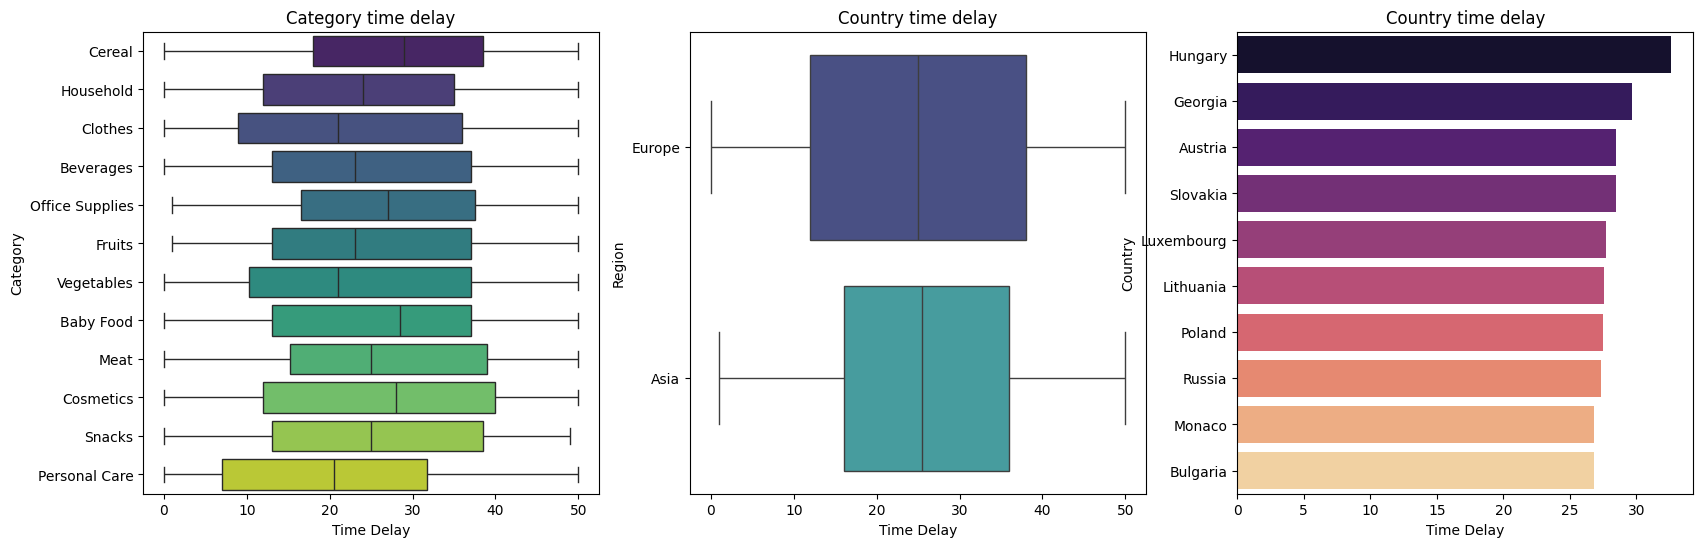

In [ ]:
clean_data_country = clean_data.groupby("Country")["Time Delay"].mean().sort_values(ascending=False).head(10)



fig, ax = plt.subplots(1, 3, figsize=(20, 6))

sns.boxplot(data=clean_data, x="Time Delay", y="Product Category", palette="viridis", ax=ax[0])
ax[0].set_title("Category time delay")
ax[0].set_xlabel("Time Delay")
ax[0].set_ylabel("Category")

sns.boxplot(data=clean_data, x="Time Delay", y="region", palette="mako", ax=ax[1])
ax[1].set_title("Country time delay")
ax[1].set_xlabel("Time Delay")
ax[1].set_ylabel("Region")

sns.barplot(x=clean_data_country.values, y=clean_data_country.index, palette= "magma", ax=ax[2])
ax[2].set_title("Country time delay")
ax[2].set_xlabel("Time Delay")
ax[2].set_ylabel("Country")

plt.tight_layout
plt.show()

**Для категорій** на графіку можна побачити, що медіаний час знаходиться в інтрвалі ~20-30 днів.Найдовший середній час відвантаження спостерігається в категоріях Cosmetics, Meat, Snacks,тоді як Personal Care має найменший середній показник .Загалом різниця між категоріями не є дуже великою, що свідчить про відносно однакову швидкість обробки замовлень для різних товарів.

**Для Регіон** на графіку видно, що регіони Europe та Asia мають схожий розподіл часу відвантаження. Медіанний час доставки становить близько 25 днів, а максимальні значення сягають приблизно 50 днів. Це свідчить про відсутність суттєвих відмінностей у швидкості відвантаження між регіонами.

**Для країн** найбільший середній час в країнах Угорщина,Грузія,Австрія.Середній час досягає ~28-32 днів.Найменнше середнє відвавнтаження серед країн топ-10 має країна Болгарія.Загалом різниця між країнами становить близько 5–7 днів, що може бути пов'язано з особливостями логістики та географічним розташуванням.

#Проаналізуємо, чи залежить прибуток від часу, необхідного на відвантаження товару

<Axes: xlabel='Time Delay', ylabel='Profit'>

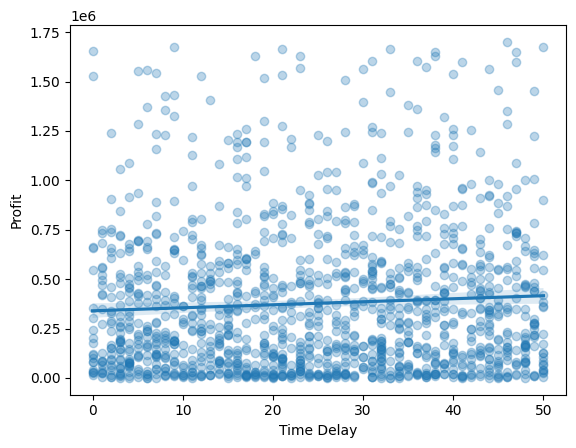

In [ ]:
sns.regplot(data=clean_data,x="Time Delay", y="Profit",scatter_kws={"alpha":0.3})


На графіку видно, що прибуток не має сильної залежності від часу відвантаження товару. Хоча лінія тренду трохи зростає, точки сильно розкидані, тому вплив часу відвантаження на прибуток є незначним. Отже, суттєвої залежності між прибутком і затримкою відвантаження не виявлено.

#Динаміку продажів (у часі) у розрізі категорій товарів, країн, регіонів

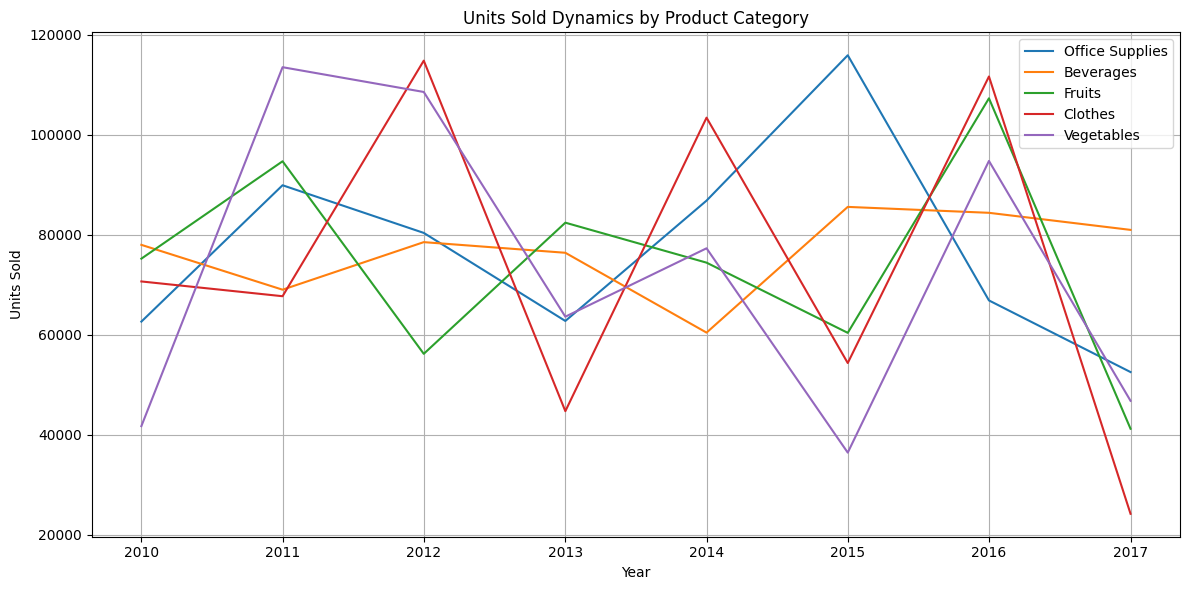

In [ ]:
top_5_categories = (
    clean_data.groupby(["Product Category"])["Units Sold"]
    .sum()
    .sort_values(ascending=False)
    .head(5)
    .index
)

sales_category = (
    clean_data[clean_data["Product Category"].isin(top_5_categories)]
    .groupby(["Year", "Product Category"])["Units Sold"]
    .sum()
    .reset_index()
)

plt.figure(figsize=(12,6))

for category in top_5_categories:
    category_data = sales_category[sales_category["Product Category"] == category]
    plt.plot(category_data["Year"], category_data["Units Sold"], label=category)

plt.title("Units Sold Dynamics by Product Category")
plt.xlabel("Year")
plt.ylabel("Units Sold")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Було проаналізовано динаміку продажів п'яти найпопулярніших категорій товарів у розрізі місяців.Найбільш продавалися катагорії Beverages, Office Supplies та Fruits,де періодично виникають піковіві значення.Для всіх категорій продажі змінюються від місяця до місяця: іноді спостерігаються різкі підйоми та спади. Чіткої тенденції до постійного зростання або зменшення продажів не виявлено.

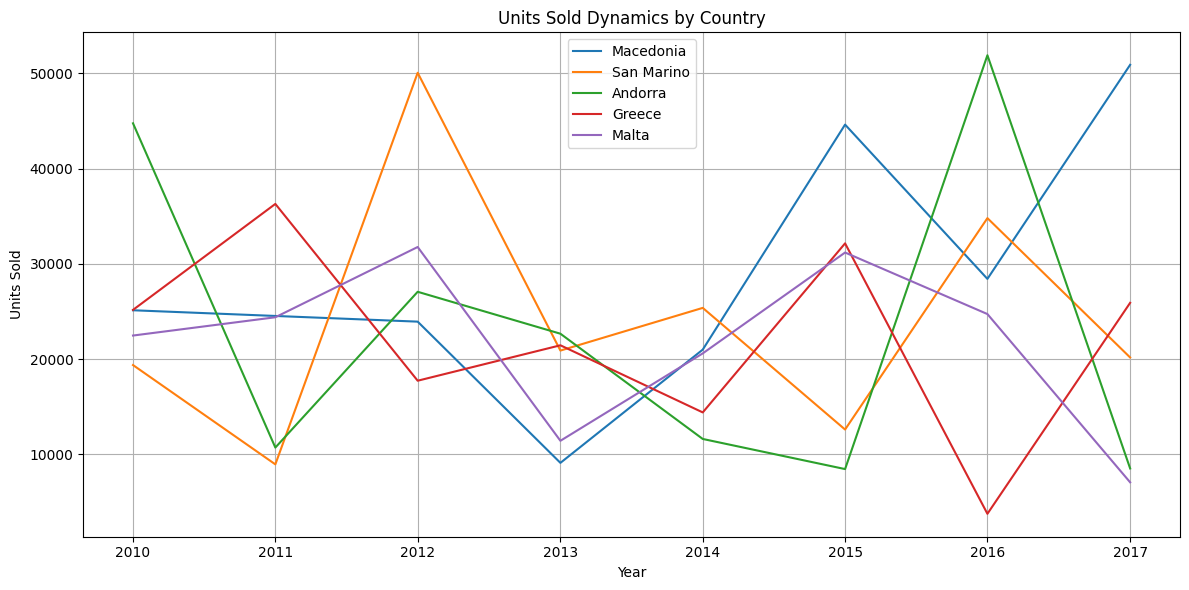

In [ ]:
top_5_country = (
    clean_data.groupby(["Country"])["Units Sold"]
    .sum()
    .sort_values(ascending=False)
    .head(5)
    .index
)

sales_country = (
    clean_data[clean_data["Country"].isin(top_5_country)]
    .groupby(["Year", "Country"])["Units Sold"]
    .sum()
    .reset_index()
)

plt.figure(figsize=(12,6))

for country in top_5_country:
    country_data = sales_country[sales_country["Country"] == country]
    plt.plot(country_data["Year"], country_data["Units Sold"], label=country)

plt.title("Units Sold Dynamics by Country")
plt.xlabel("Year")
plt.ylabel("Units Sold")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

За графіком видно, що продажі в країнах змінювалися нерівномірно протягом усього періоду. Найбільші обсяги продажів спостерігалися в Macedonia, де наприкінці періоду відбувся різкий стрибок продажів. Для інших країн характерні періодичні підйоми та спади, але чіткої тенденції до стабільного зростання або зниження не спостерігається.

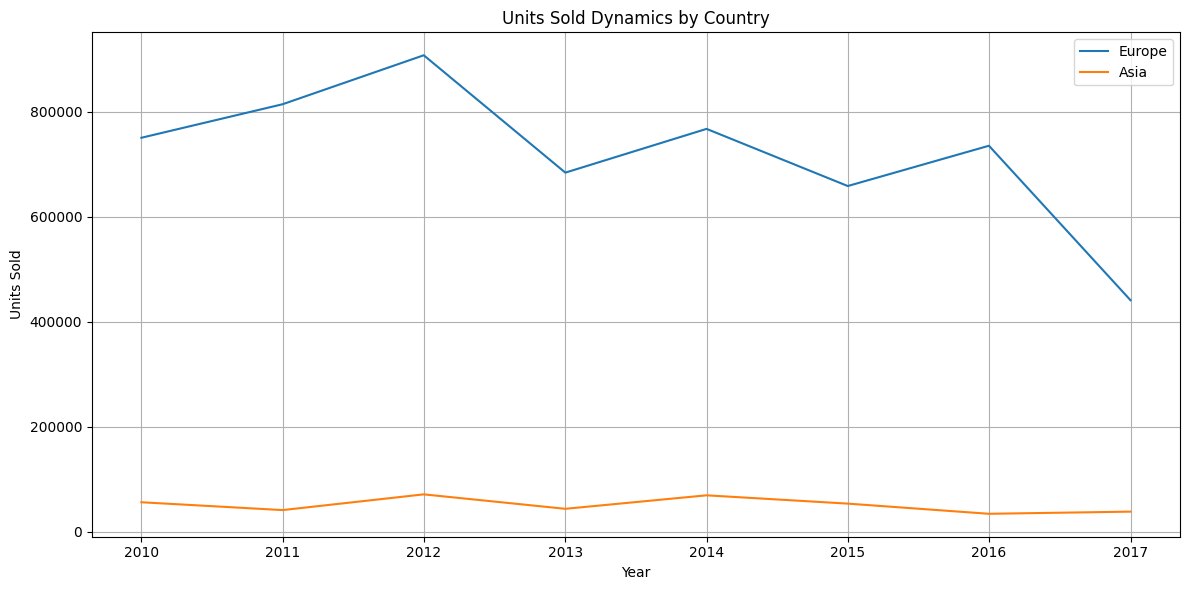

In [ ]:
regions = (
    clean_data.groupby(["region"])["Units Sold"]
    .sum()
    .sort_values(ascending=False)
    .head(5)
    .index
)

sales_region = (
    clean_data[clean_data["region"].isin(regions)]
    .groupby(["Year", "region"])["Units Sold"]
    .sum()
    .reset_index()
)

plt.figure(figsize=(12,6))

for region in regions:
    region_data = sales_region[sales_region["region"] == region]
    plt.plot(region_data["Year"], region_data["Units Sold"], label=region)

plt.title("Units Sold Dynamics by Country")
plt.xlabel("Year")
plt.ylabel("Units Sold")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

За графіком видно, що регіон Europe має вищі обсяги продажів, ніж Asia, протягом більшої частини періоду. Для Європи характерні помітні коливання: спостерігаються як різкі зростання, так і спади продажів. В Азії обсяги продажів змінюються менш суттєво та залишаються відносно стабільними. Загалом Європа є основним регіоном за кількістю проданих одиниць товару.

#Aналіз продажів товарів за днями тижня

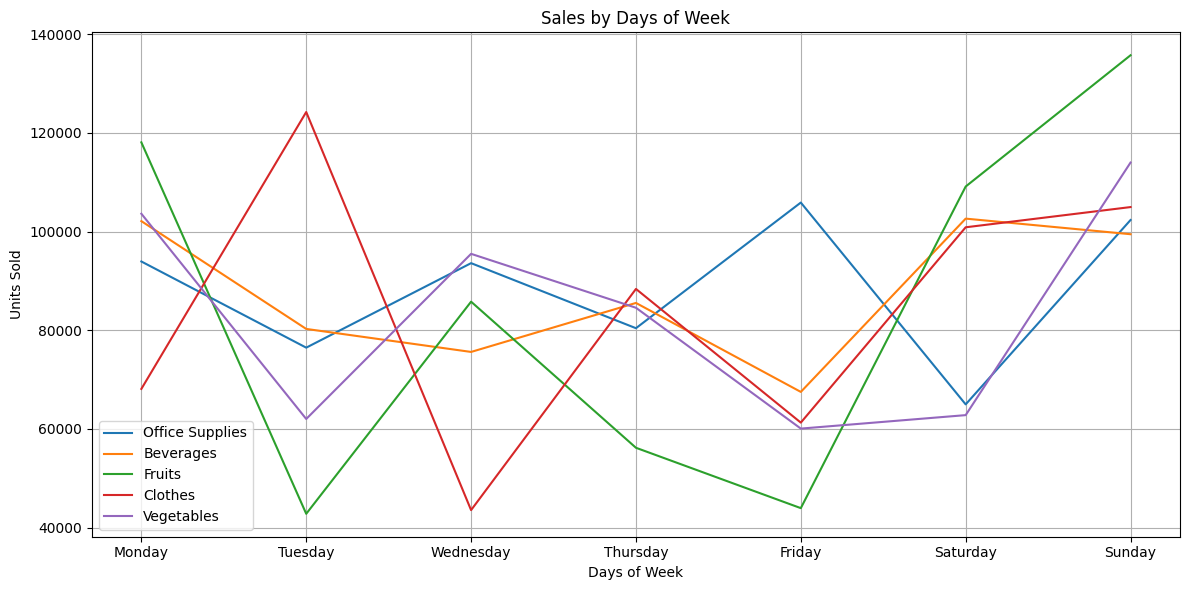

In [ ]:
top_5_categories = (
    clean_data.groupby("Product Category")["Units Sold"]
    .sum()
    .sort_values(ascending=False)
    .head(5)
    .index
)

sales_weekday = (
    clean_data[clean_data["Product Category"].isin(top_5_categories)]
    .groupby(["Product Category", "Day of Week"])["Units Sold"]
    .sum()
    .reset_index()
)

days_order = [
    "Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"
]

sales_weekday["Day of Week"] = pd.Categorical(
    sales_weekday["Day of Week"],
    categories=days_order,
    ordered=True
)

sales_weekday = sales_weekday.sort_values("Day of Week")


plt.figure(figsize=(12, 6))

for category in top_5_categories:
    weekday_data = sales_weekday[
        sales_weekday["Product Category"] == category
    ]

    plt.plot(
        weekday_data["Day of Week"],
        weekday_data["Units Sold"],
        label=category
    )

plt.title("Sales by Days of Week")
plt.xlabel("Days of Week")
plt.ylabel("Units Sold")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Було проаналізовано продажі п'яти найпопулярніших категорій товарів за днями тижня. Для більшості категорій продажі помітно змінюються залежно від дня. Найвищі значення часто спостерігаються у вихідні дні, особливо в неділю. Категорія Fruits має найбільший пік продажів у неділю, а для Clothes найвищі продажі спостерігаються у вівторок. Загалом попит на товари протягом тижня нерівномірний, що може свідчити про наявність певної сезонності за днями тижня.

## Reporting

У цьому проєкті було проведено повний аналіз продажів компанії, яка працює на міжнародному ринку та продає товари через онлайн- і офлайн-канали.

Спочатку було виконано огляд даних із трьох таблиць: `events`, `products` та `countries`. Після цього таблиці були об'єднані за ключовими полями: `Product ID` та `Country Code`. Це дозволило аналізувати продажі не лише за окремими замовленнями, а й у розрізі категорій товарів, країн, регіонів та каналів продажу.

Під час очищення даних були перевірені пропущені значення, дублікати, типи даних та аномалії. Пропуски в ключових числових полях були видалені, оскільки вони могли спотворити основні бізнес-метрики. Також були стандартизовані текстові значення, наприклад канал продажу `Online/online`.

У процесі аналізу були розраховані основні метрики: загальна кількість замовлень, дохід, витрати, прибуток, кількість проданих одиниць, середній час відвантаження та кількість охоплених країн.

Аналіз показав, що найбільший внесок у продажі мають окремі категорії товарів, країни та регіони. Офлайн-продажі трохи випереджають онлайн-продажі за кількістю проданих одиниць та прибутком, однак різниця між каналами невелика.

Динаміка продажів у часі показала, що продажі змінюються нерівномірно. Для більшості категорій, країн та регіонів спостерігаються періодичні підйоми та спади, але чіткої стабільної тенденції до зростання або зниження не виявлено.

Аналіз часу відвантаження показав, що середній час між замовленням і відвантаженням відрізняється залежно від категорії товару, країни та регіону. Проте сильного впливу часу відвантаження на прибуток не виявлено.

Також було проаналізовано продажі за днями тижня. Для деяких категорій спостерігаються вищі продажі в окремі дні, особливо у вихідні. Це може свідчити про певну сезонність попиту в межах тижня.

З бізнесової точки зору компанії варто звернути увагу на найприбутковіші країни, категорії товарів із найбільшими продажами та канали продажу, які дають найкращий результат. Також доцільно аналізувати періоди пікових продажів, щоб краще планувати запаси, логістику та маркетингові кампанії.
